In [ ]:
                #--------Outlier---------#
# An outlier is a data point that is very different from the rest of the data.

# Some models are very sensitive to outliers: Weight Base model
    # Linear Regression
    # Logistic Regression
    # KNN
    # SVM
    # AdaBoost
    # Deeplearning
# Less sensitive: Tree base model
    # Decision Tree
    # Random Forest
    # XgBoost
    # Gradient Boost

# Note: It is good practice to treat outlier

In [ ]:
# How to treat outliers

# 1. Remove them (Trimming)
    # Trimming means completely removing extreme values from the dataset.

# 2. Limit them (Capping / Winsorization)
    # Instead of removing outliers, we replace extreme values with a boundary value.


In [ ]:
# How detect outlier

# There are 4 major ways:
    # Statistical methods
    # Visualization
    # Distance-based methods
    # ML-based anomaly detection

# IQR Method: For skewed data
# Z-Score Method: For normal distribution
# Visualization: Box Plot
# Percentile method: For other distribution
# vWinsorization

In [ ]:
# Outlier removal using Z-score

# In this technique data must be normally distributed or almost normally distributed
# How to detect:
    # μ+SD, μ-SD =68% Data
    # μ+2SD, μ-2SD =95% Data
    # μ+3SD, μ-3SD =99.7% Data
    # μ+SD<data, μ-SD>Data = Outlier
# Treat:
    # Trimming
    # Capping

In [2]:
# Code Example:

# Import required libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
# Import Dataset
df = pd.read_csv('placement.csv')
df.shape

(1000, 3)

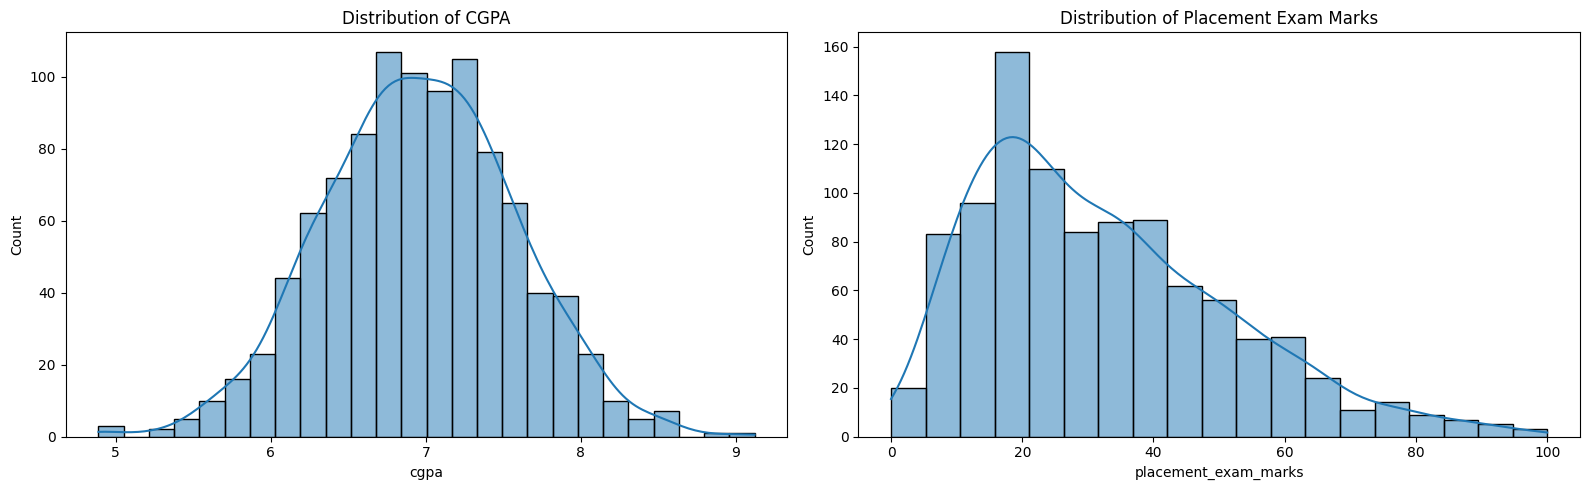

In [ ]:
# Chek the distribution of column
plt.figure(figsize=(16, 5))
plt.subplot(1, 2, 1)
sns.histplot(df['cgpa'], kde=True)
plt.title('Distribution of CGPA')

plt.subplot(1, 2, 2)
sns.histplot(df['placement_exam_marks'], kde=True)
plt.title('Distribution of Placement Exam Marks')
plt.tight_layout()
plt.show()

In [5]:
# Findout statistics
print("Mean value of cgpa",df['cgpa'].mean())
print("Std value of cgpa",df['cgpa'].std())
print("Min value of cgpa",df['cgpa'].min())
print("Max value of cgpa",df['cgpa'].max())

Mean value of cgpa 6.96124
Std value of cgpa 0.6158978751323896
Min value of cgpa 4.89
Max value of cgpa 9.12


In [6]:
# Finding the boundary values
print("Highest allowed",df['cgpa'].mean() + 3*df['cgpa'].std())
print("Lowest allowed",df['cgpa'].mean() - 3*df['cgpa'].std())

Highest allowed 8.808933625397168
Lowest allowed 5.113546374602832


In [7]:
# Finding the outliers
df[(df['cgpa'] > 8.80) | (df['cgpa'] < 5.11)]

,cgpa,placement_exam_marks,placed
485,4.92,44.0,1
995,8.87,44.0,1
996,9.12,65.0,1
997,4.89,34.0,0
999,4.90,10.0,1


In [9]:
# Perform trimming
new_df = df[(df['cgpa'] < 8.80) & (df['cgpa'] > 5.11)]

In [10]:
# Approach 2

# Calculating the Zscore
df['cgpa_zscore'] = (df['cgpa'] - df['cgpa'].mean())/df['cgpa'].std()

In [11]:
df[df['cgpa_zscore'] > 3]

,cgpa,placement_exam_marks,placed,cgpa_zscore
995,8.87,44.0,1,3.099150
996,9.12,65.0,1,3.505062


In [12]:
df[df['cgpa_zscore'] < -3]

,cgpa,placement_exam_marks,placed,cgpa_zscore
485,4.92,44.0,1,-3.314251
997,4.89,34.0,0,-3.362960
999,4.90,10.0,1,-3.346724


In [13]:
df[(df['cgpa_zscore'] > 3) | (df['cgpa_zscore'] < -3)]

,cgpa,placement_exam_marks,placed,cgpa_zscore
485,4.92,44.0,1,-3.314251
995,8.87,44.0,1,3.099150
996,9.12,65.0,1,3.505062
997,4.89,34.0,0,-3.362960
999,4.90,10.0,1,-3.346724


In [14]:
# Trimming 
new_df = df[(df['cgpa_zscore'] < 3) & (df['cgpa_zscore'] > -3)]

In [ ]:
# Capping technique
upper_limit = df['cgpa'].mean() + 3*df['cgpa'].std()
lower_limit = df['cgpa'].mean() - 3*df['cgpa'].std()

In [17]:
# Perform capping
df['cgpa'] = np.where(
    df['cgpa']>upper_limit,
    upper_limit,
    np.where(
        df['cgpa']<lower_limit,
        lower_limit,
        df['cgpa']
    )
)

In [ ]:
# Outlier Handling Using IQR

# It measures the spread of the middle 50% of the data.
# Use when:
    # Dataset is large
    # Outliers are clearly errors

In [ ]:
# Read dataset
df = pd.read_csv('placement.csv')

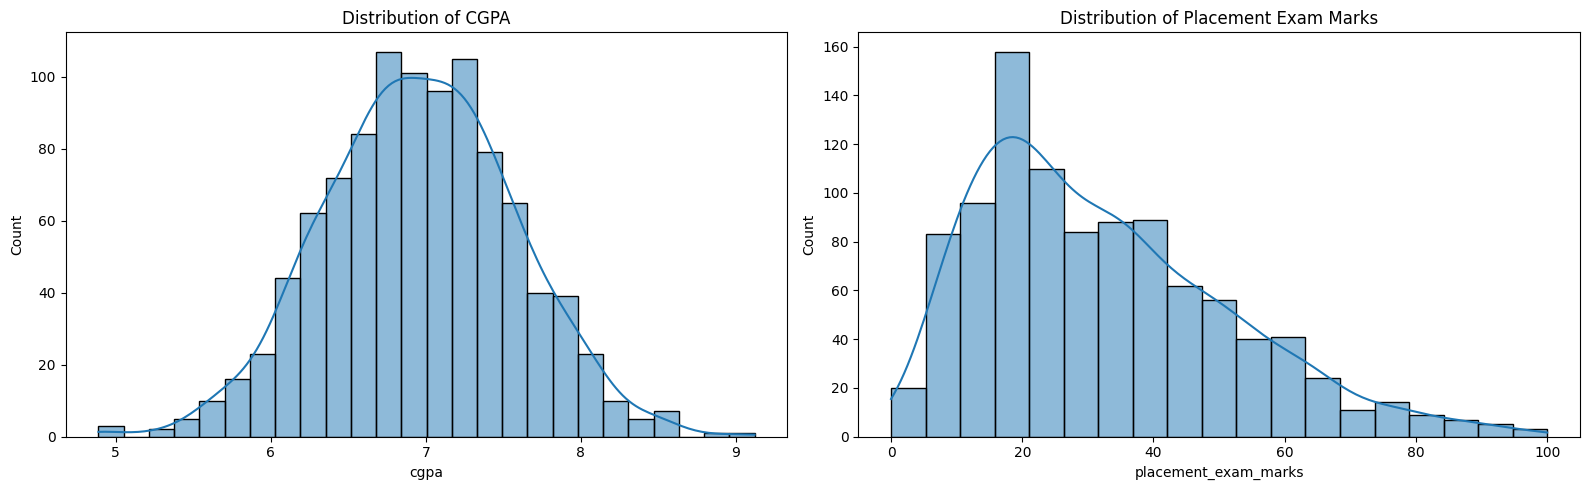

In [20]:
# SHow the Distribution
plt.figure(figsize=(16, 5))
plt.subplot(1, 2, 1)
sns.histplot(df['cgpa'], kde=True)
plt.title('Distribution of CGPA')

plt.subplot(1, 2, 2)
sns.histplot(df['placement_exam_marks'], kde=True)
plt.title('Distribution of Placement Exam Marks')
plt.tight_layout()
plt.show()

In [21]:
# Show basic Statistics
df['placement_exam_marks'].describe()

count    1000.000000
mean       32.225000
std        19.130822
min         0.000000
25%        17.000000
50%        28.000000
75%        44.000000
max       100.000000
Name: placement_exam_marks, dtype: float64

<Axes: ylabel='placement_exam_marks'>

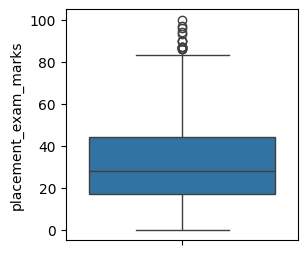

In [23]:
# Check the outlier
plt.figure(figsize=(3,3))
sns.boxplot(df['placement_exam_marks'])

In [25]:
# Finding the IQR
percentile25 = df['placement_exam_marks'].quantile(0.25)
percentile75 = df['placement_exam_marks'].quantile(0.75)
iqr = percentile75 - percentile25

In [27]:
# Findout upper and lower limit
upper_limit = percentile75 + 1.5 * iqr
lower_limit = percentile25 - 1.5 * iqr
print("Upper limit",upper_limit)
print("Lower limit",lower_limit)

Upper limit 84.5
Lower limit -23.5


In [28]:
# Finding Outlier
df[df['placement_exam_marks'] > upper_limit]

,cgpa,placement_exam_marks,placed
9,7.75,94.0,1
40,6.60,86.0,1
61,7.51,86.0,0
134,6.33,93.0,0
162,7.80,90.0,0
283,7.09,87.0,0
290,8.38,87.0,0
311,6.97,87.0,1
324,6.64,90.0,0
630,6.56,96.0,1


In [29]:
df[df['placement_exam_marks'] < lower_limit]

,cgpa,placement_exam_marks,placed


In [31]:
# Perform trimming
new_df = df[df['placement_exam_marks'] < upper_limit]
new_df.shape

(985, 3)

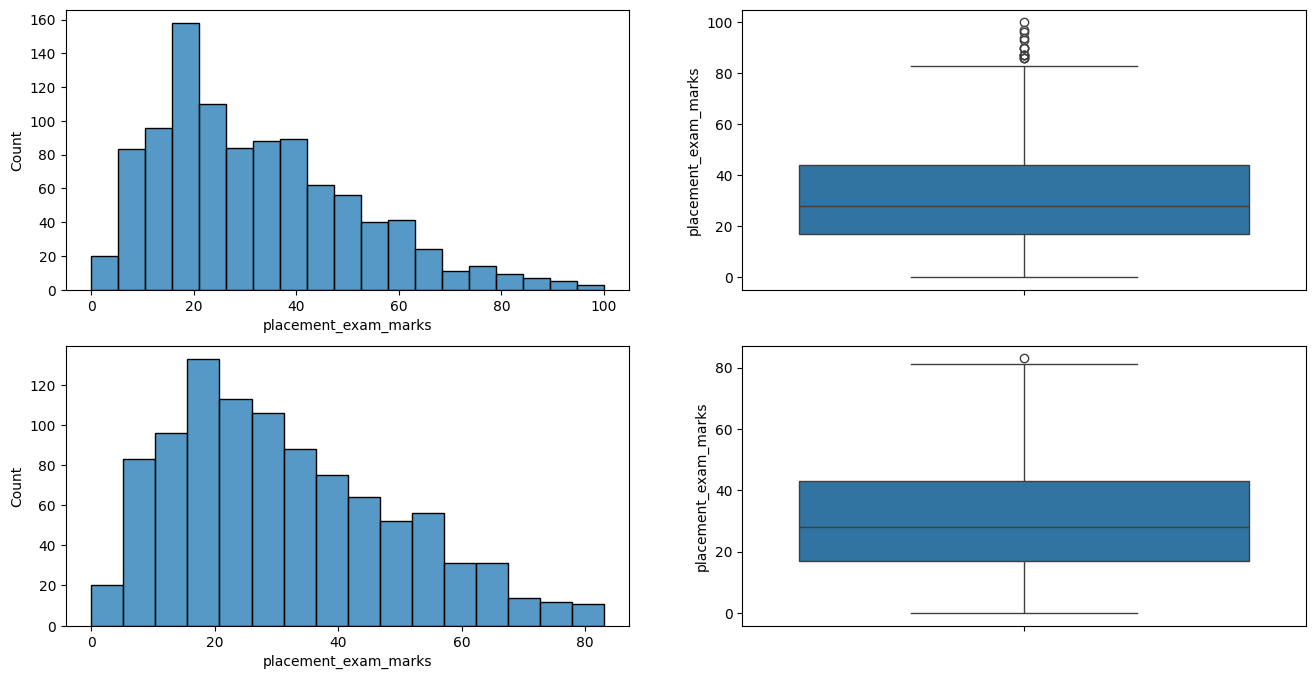

In [34]:
#Comparing

plt.figure(figsize=(16,8))
plt.subplot(2,2,1)
sns.histplot(df['placement_exam_marks'])
plt.subplot(2,2,2)
sns.boxplot(df['placement_exam_marks'])

plt.subplot(2,2,3)
sns.histplot(new_df['placement_exam_marks'])

plt.subplot(2,2,4)
sns.boxplot(new_df['placement_exam_marks'])

plt.show()

In [35]:
# Perform CApping
new_df_cap = df.copy()

new_df_cap['placement_exam_marks'] = np.where(
    new_df_cap['placement_exam_marks'] > upper_limit,
    upper_limit,
    np.where(
        new_df_cap['placement_exam_marks'] < lower_limit,
        lower_limit,
        new_df_cap['placement_exam_marks']
    )
)

In [ ]:
# Shape remain same
new_df_cap.shape

(1000, 3)

In [ ]:
# HAndling Outlier using Percentaile
# Instead of using IQR formula, we directly define cut-off values based on percentiles.

# For example:
    # Lower limit → 1st percentile (or 5th)
    # Upper limit → 99th percentile (or 95th)
    # Anything outside these limits = outlier.
    # It works well for skewed data
    # It’s more flexible than IQR

In [3]:
# Code Example
df = pd.read_csv('weight-height.csv')

In [4]:
# Show basic statistics
df['Height'].describe()

count    10000.000000
mean        66.367560
std          3.847528
min         54.263133
25%         63.505620
50%         66.318070
75%         69.174262
max         78.998742
Name: Height, dtype: float64

<Axes: ylabel='Height'>

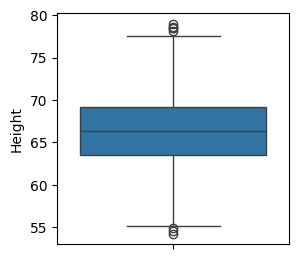

In [6]:
# Check any outlier
plt.figure(figsize=(3,3))
sns.boxplot(df['Height'])

In [7]:
# Calculate upper limit
upper_limit = df['Height'].quantile(0.99)
upper_limit

np.float64(74.7857900583366)

In [8]:
# Calculate lower limit
lower_limit = df['Height'].quantile(0.01)
lower_limit

np.float64(58.13441158671655)

<Axes: ylabel='Height'>

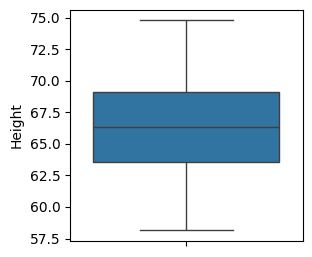

In [11]:
# Perform trimming
new_df = df[(df['Height'] <= 74.78) & (df['Height'] >= 58.13)]
plt.figure(figsize=(3,3))
sns.boxplot(new_df['Height'])